# Aircraft Engine Predictive Maintenance
## Exploratory Data Analysis (EDA)
Dataset:
NASA C-MAPSS FD004

# Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option("display.max_columns", None)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
columns = [
    "unit",
    "cycle",
    "setting1",
    "setting2",
    "setting3"
]

columns += [f"s{i}" for i in range(1, 22)]

print(columns)
print(f"Total Columns: {len(columns)}")

['unit', 'cycle', 'setting1', 'setting2', 'setting3', 's1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21']
Total Columns: 26


In [3]:
import os

print(os.getcwd())

d:\Project\aircraft maintenance system\NOTEBOOK


# Load Dataset


In [4]:
train = pd.read_csv(
    "../data/raw/train_FD004.txt",
    sep=r"\s+",
    header=None
)

# Dataset Overview

In [5]:
train = train.dropna(axis=1)

train.columns = columns

train.head()

,unit,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,5.70,137.36,2211.86,8311.32,1.01,41.69,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,13.61,332.10,2323.66,8713.60,1.07,43.94,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,5.69,138.18,2211.92,8306.69,1.01,41.66,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,5.70,137.98,2211.88,8312.35,1.02,41.68,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,9.00,174.82,1915.22,7994.94,0.93,36.48,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754



# Data Quality Check

In [6]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
unit,61249.0,124.325181,71.995350,1.0000,60.0000,126.0000,185.0000,249.0000
cycle,61249.0,134.311417,89.783389,1.0000,62.0000,123.0000,191.0000,543.0000
setting1,61249.0,23.999823,14.780722,0.0000,10.0046,25.0014,41.9981,42.0080
setting2,61249.0,0.571347,0.310703,0.0000,0.2507,0.7000,0.8400,0.8420
setting3,61249.0,94.031576,14.251954,60.0000,100.0000,100.0000,100.0000,100.0000
s1,61249.0,472.882435,26.436832,445.0000,445.0000,462.5400,491.1900,518.6700
s2,61249.0,579.420056,37.342647,535.4800,549.3300,555.7400,607.0700,644.4200
s3,61249.0,1417.896600,106.167598,1242.6700,1350.5500,1367.6800,1497.4200,1613.0000
s4,61249.0,1201.915359,119.327591,1024.4200,1119.4900,1136.9200,1302.6200,1440.7700
s5,61249.0,8.031626,3.622872,3.9100,3.9100,7.0500,10.5200,14.6200


In [7]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 61249 entries, 0 to 61248
Data columns (total 26 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   unit      61249 non-null  int64  
 1   cycle     61249 non-null  int64  
 2   setting1  61249 non-null  float64
 3   setting2  61249 non-null  float64
 4   setting3  61249 non-null  float64
 5   s1        61249 non-null  float64
 6   s2        61249 non-null  float64
 7   s3        61249 non-null  float64
 8   s4        61249 non-null  float64
 9   s5        61249 non-null  float64
 10  s6        61249 non-null  float64
 11  s7        61249 non-null  float64
 12  s8        61249 non-null  float64
 13  s9        61249 non-null  float64
 14  s10       61249 non-null  float64
 15  s11       61249 non-null  float64
 16  s12       61249 non-null  float64
 17  s13       61249 non-null  float64
 18  s14       61249 non-null  float64
 19  s15       61249 non-null  float64
 20  s16       61249 non-null  float64
 21  

In [8]:
missing_values = train.isnull().sum()

print(missing_values)

unit        0
cycle       0
setting1    0
setting2    0
setting3    0
s1          0
s2          0
s3          0
s4          0
s5          0
s6          0
s7          0
s8          0
s9          0
s10         0
s11         0
s12         0
s13         0
s14         0
s15         0
s16         0
s17         0
s18         0
s19         0
s20         0
s21         0
dtype: int64


In [9]:
print(f"Total Missing Values: {missing_values.sum()}")

Total Missing Values: 0


In [10]:
duplicates = train.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


In [11]:
print(f"Rows    : {train.shape[0]}")
print(f"Columns : {train.shape[1]}")

Rows    : 61249
Columns : 26


# Engine Analysis

In [12]:
print(f"Number of Engines: {train['unit'].nunique()}")

Number of Engines: 249


In [13]:
engine_cycles = train.groupby("unit")["cycle"].max()

engine_cycles.head()

unit
1    321
2    299
3    307
4    274
5    193
Name: cycle, dtype: int64

In [14]:
engine_cycles.describe()

count    249.00000
mean     245.97992
std       73.11080
min      128.00000
25%      190.00000
50%      234.00000
75%      290.00000
max      543.00000
Name: cycle, dtype: float64

In [15]:
train[["setting1", "setting2", "setting3"]].describe()

,setting1,setting2,setting3
count,61249.000000,61249.000000,61249.000000
mean,23.999823,0.571347,94.031576
std,14.780722,0.310703,14.251954
min,0.000000,0.000000,60.000000
25%,10.004600,0.250700,100.000000
50%,25.001400,0.700000,100.000000
75%,41.998100,0.840000,100.000000
max,42.008000,0.842000,100.000000


# 6. Sensor Analysis

In [16]:
sensor_columns = [f"s{i}" for i in range(1, 22)]

print(sensor_columns)

['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21']


In [17]:
train[sensor_columns].std().sort_values()

s16      0.004685
s10      0.127681
s15      0.750374
s11      3.243492
s5       3.622872
s19      5.369424
s6       5.444017
s21      5.962697
s20      9.936396
s1      26.436832
s17     27.808283
s2      37.342647
s14     85.670543
s3     106.167598
s4     119.327591
s13    128.197859
s12    138.479109
s8     145.348243
s18    145.472491
s7     146.880210
s9     336.927547
dtype: float64

In [18]:
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

In [19]:
pio.templates.default = "plotly_white"

In [20]:
engine_life_df = engine_cycles.reset_index()
engine_life_df.columns = ["Engine", "Maximum Cycle"]

fig = px.histogram(
    engine_life_df,
    x="Maximum Cycle",
    nbins=25,
    title="Distribution of Engine Life"
)

fig.update_layout(
    title_x=0.5,
    xaxis_title="Maximum Cycle",
    yaxis_title="Number of Engines"
)

fig.show()

In [21]:
records = train.groupby("unit").size().reset_index(name="Records")

fig = px.bar(
    records,
    x="unit",
    y="Records",
    title="Records per Engine"
)

fig.update_layout(
    title_x=0.5,
    xaxis_title="Engine ID",
    yaxis_title="Records"
)

fig.show()

In [22]:
engine1 = train[train["unit"] == 1]

fig = px.line(
    engine1,
    x="cycle",
    y=["s2", "s3", "s4", "s7", "s11"],
    title="Selected Sensor Trends for Engine 1"
)

fig.show()

# 7. Correlation Analysis

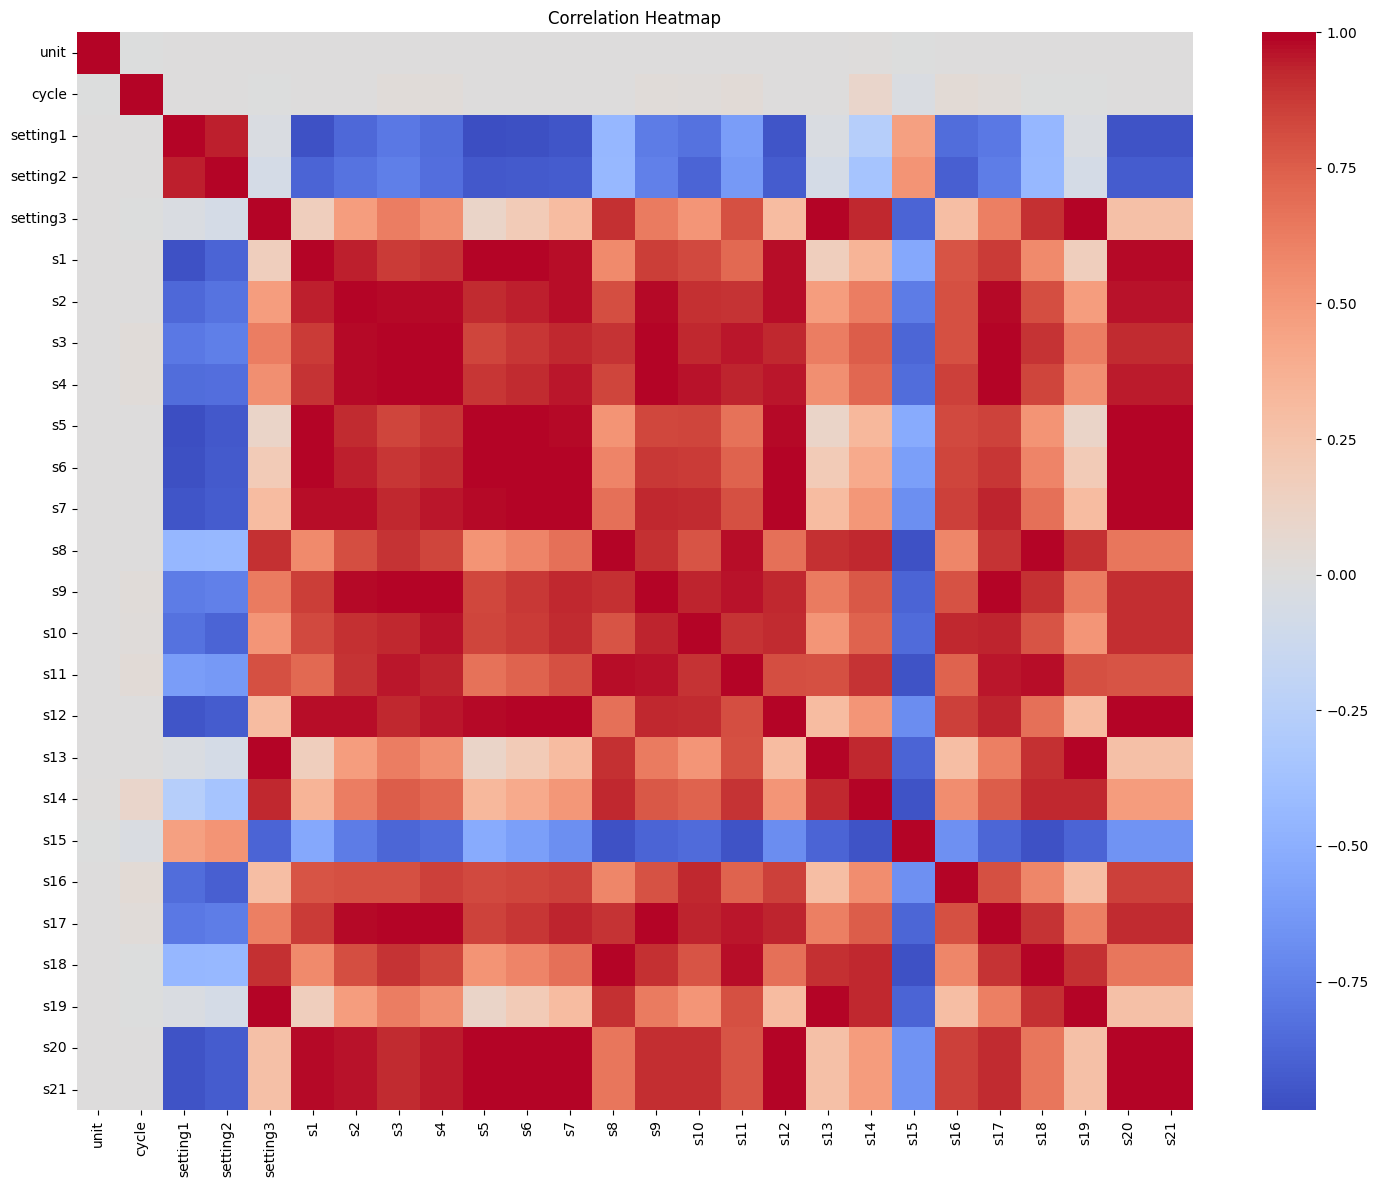

In [23]:
corr = train.corr(numeric_only=True)

plt.figure(figsize=(18, 14))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [24]:
train.to_csv(r"D:\Project\aircraft maintenance system\data\processed\train_clean.csv", index=False)

print("✅ Clean dataset saved successfully!")

✅ Clean dataset saved successfully!


# 8. Observations

- Dataset contains 248 aircraft engines.
- No missing values found.
- No duplicate records found.
- Engine life varies across units.
- Some sensors (e.g., s10 and s16) have very low variance.
- Several sensors are strongly correlated.
- The dataset is clean and ready for preprocessing.